# Linear Regression
- this flow chart was made by me in obsidian, and this showcase how different classes of scikit learn implemented Linear Regression and when to prefer which 

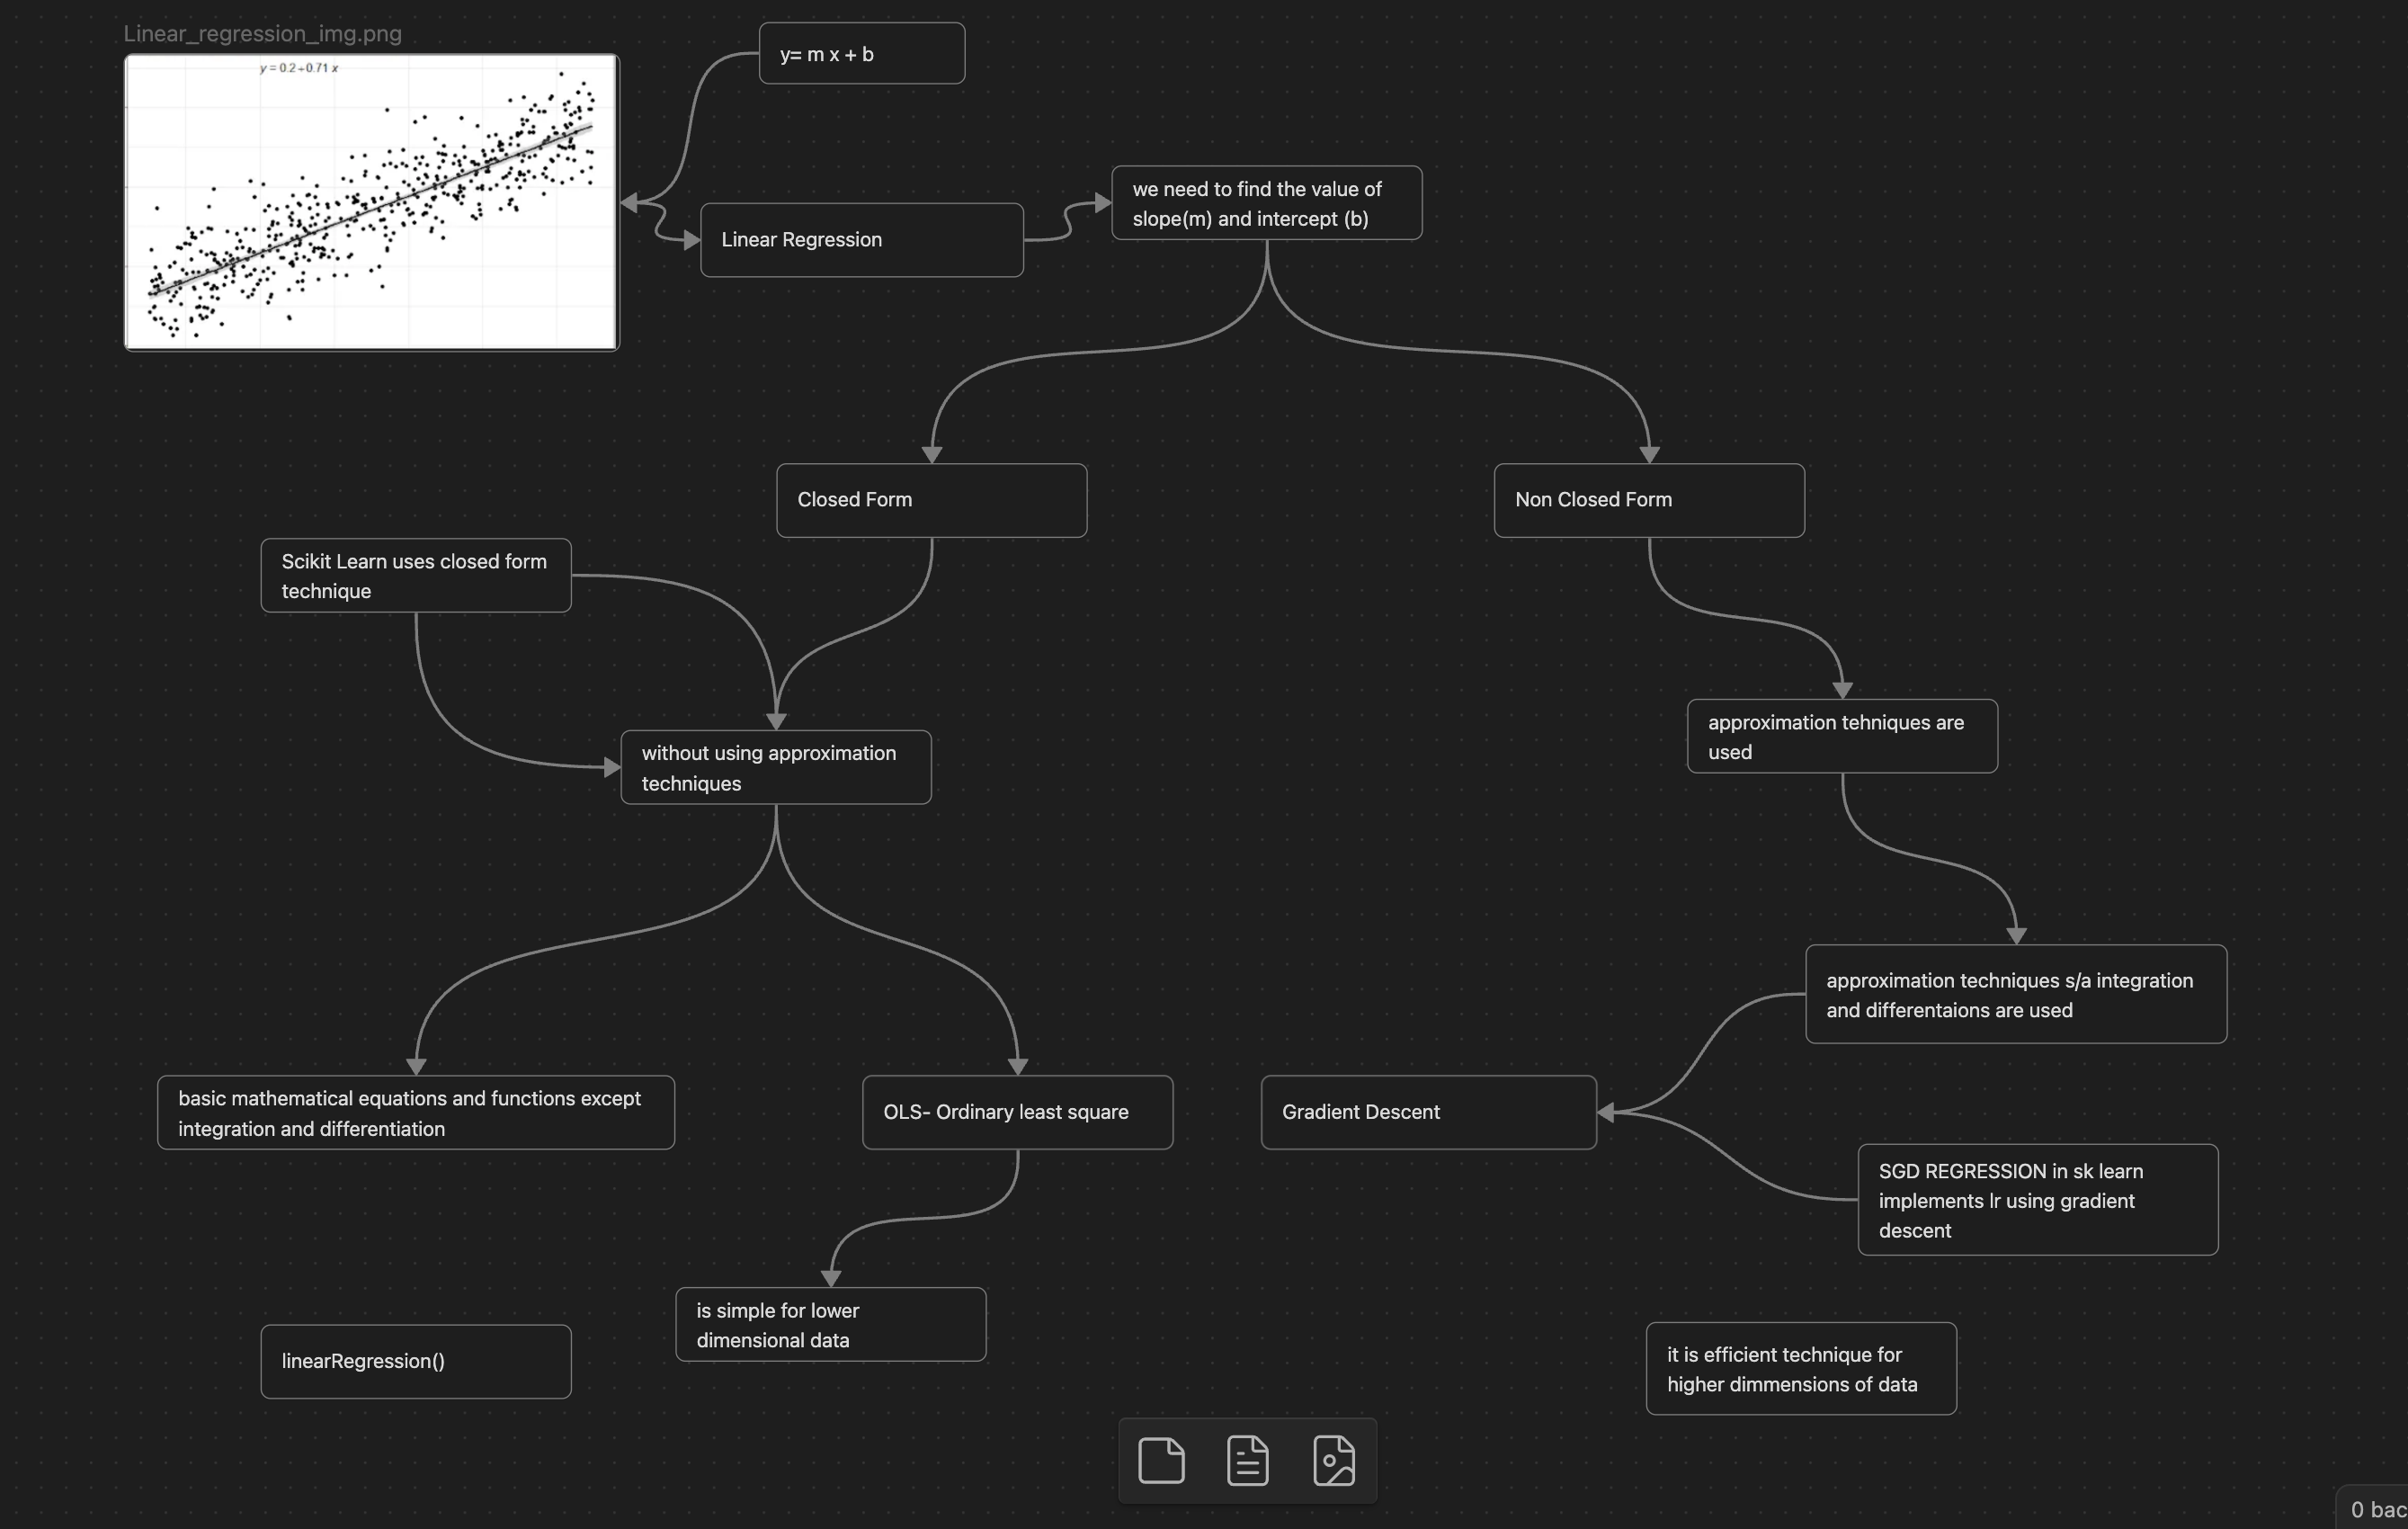

## This notebook primarily contains a very basic usecase of Linear Regression 
> I have uploaded other notebooks implementing this same function of OLS - Ordinary Least Square and Gradient Descent from scratch in my other notebooks
## Linear Regression
Linear Regression models the relationship between a dependent variable `y` and one or more independent variables `x` by fitting a straight line:         
y = mx + b                
where `m` is the slope (coefficient) and `b` is the intercept.              


In [88]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [89]:
df=pd.read_csv('placement.csv')

In [90]:
df.sample(10)

,cgpa,package
148,7.57,3.40
32,6.96,3.08
138,7.91,3.89
192,8.25,3.75
11,6.61,2.60
56,5.84,2.74
155,6.98,3.09
101,6.71,3.52
159,8.71,4.08
42,5.95,2.54


In [91]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


### This data was only of two dimmensions so, we can can easily observe the plot between our target variable and independent variable by simply a scatter plot

Text(0, 0.5, 'salary in lpa')

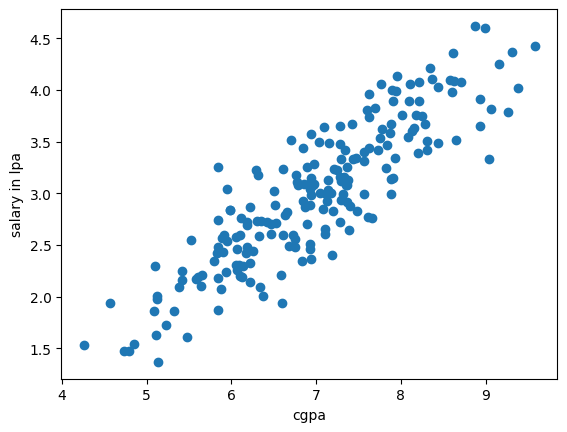

In [92]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('salary in lpa')

In [93]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

## Train Test Split (Test_size=0.2)

In [94]:
x_train, x_test, y_train ,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

This uses the OLS - Ordinary Least Square Method to find values of line that fit the two features

In [95]:
lr=LinearRegression()

In [96]:
lr.fit(x_train,y_train)

LinearRegression()

In [97]:
y_pred=lr.predict(x_test)

In [98]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

## Plotting our line for this case

Text(0, 0.5, 'salary in lpa')

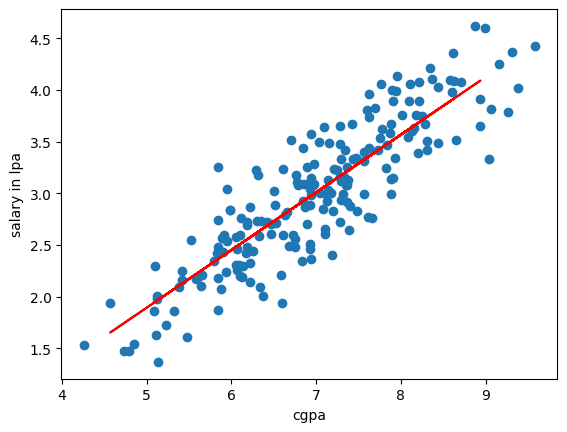

In [99]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_test,lr.predict(x_test),color='red')
plt.xlabel('cgpa')
plt.ylabel('salary in lpa')

## Slope and Intercept 

In [100]:
m=lr.coef_
m

array([0.55795197])

In [101]:
b=lr.intercept_
b

-0.8961119222429144

## Verifying that equation of line can u be used to interpret output

In [102]:
#y=mx+b
y=m*8.58 + b
y

array([3.89111601])

In [103]:
m* 10+b

array([4.68340781])

### Evaluate
#### 1. R² Score (Coefficient of Determination)

**Formula:**
R² = 1 - [ Σ(yᵢ - ŷᵢ)² / Σ(yᵢ - ȳ)² ]

**Interpretation:**
- Measures how much variance in y (dependent variable) is explained by the model
- Range: (-∞, 1]
  - 1 → Perfect fit
  - 0 → Same as predicting the mean
  - < 0 → Worse than baseline
##### Key points
- Unitless (scale independent)
- Indicates goodness of fit
- Does NOT tell actual error magnitude
---
#### 2. RMSE (Root Mean Squared Error)

**Formula:**
RMSE = √[ (1/n) * Σ(yᵢ - ŷᵢ)² ]

**Interpretation:**
- Measures average prediction error magnitude
- Range: [0, ∞)
  - 0 → Perfect prediction

##### **Key Points:**
- Same units as target variable
- Penalizes large errors more heavily
- Sensitive to outliers



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
 
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE     : {mean_squared_error(y_test, y_pred):.4f}"

R² Score : 0.7807
RMSE     : 0.1213


- **Use R² when:**
  - Comparing models
  - Evaluating explanatory power

- **Use RMSE when:**
  - You care about actual prediction error
  - Error magnitude matters in real-world units